In [2]:
from semantic_state_estimator.semantic_state_estimator import SemanticStateEstimatorWithLLaMA

EXAMPLE = 'real_robot'
LLAMA_ID = "meta-llama/Meta-Llama-3-70B-Instruct"
LLAVA_ID = "lmms-lab/llava-onevision-qwen2-72b-ov"


se = SemanticStateEstimatorWithLLaMA(
    domain=f'examples/{EXAMPLE}/domain.pddl',
    problem=f'examples/{EXAMPLE}/problem.pddl',
    nl_converter_model_id=LLAMA_ID,
    vqa_model_id=LLAVA_ID
)

predicate queries loaded from cache
Loaded LLaVA model: lmms-lab/llava-onevision-qwen2-72b-ov


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
You are using a model of type llava to instantiate a model of type llava_qwen. This is not supported for all configurations of models and can yield errors.


Loading vision tower: google/siglip-so400m-patch14-384


Loading checkpoint shards:   0%|          | 0/31 [00:00<?, ?it/s]

Model Class: LlavaQwenForCausalLM


In [3]:
from PIL import Image
import glob

files = glob.glob('examples/real_robot/*.png')

images = [
    Image.open(fname)
    for fname in files
]

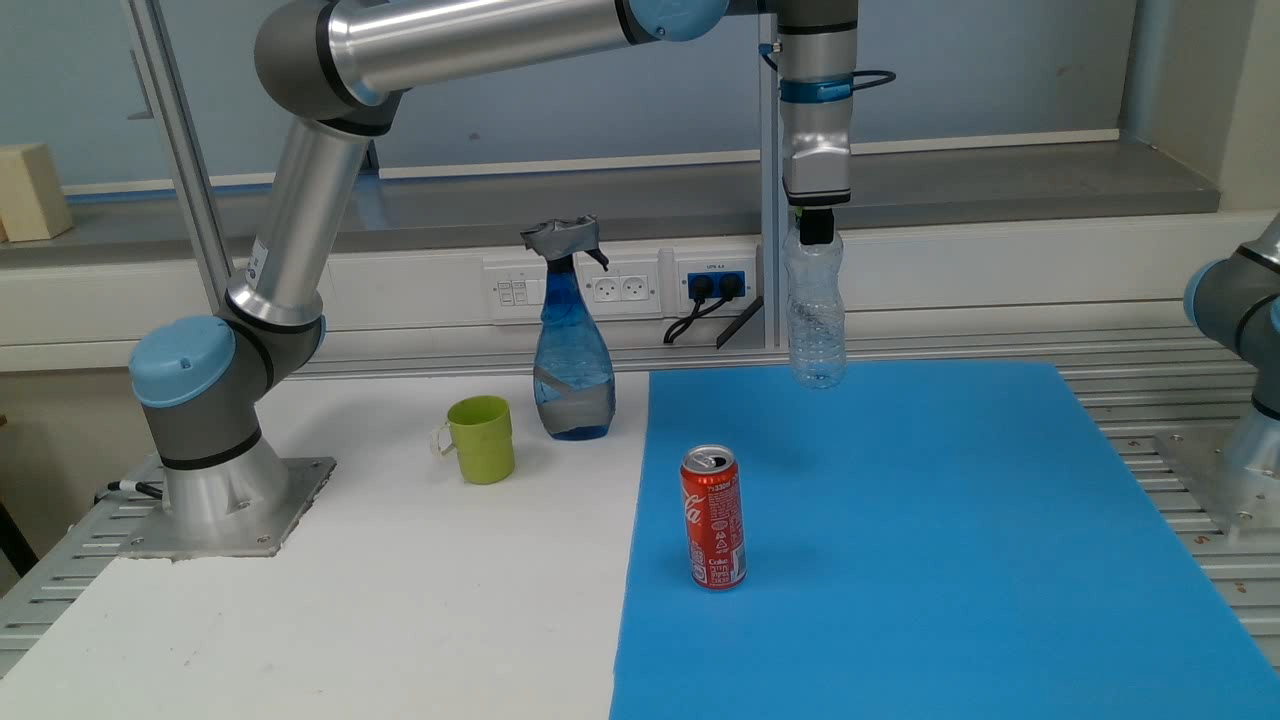

In [38]:
img = images[0]
# img = Image.open('examples/real_robot/pick bottle2.png')
img

In [39]:
logits = se.vqa_model([img], ["Is the robot's gripper currently empty?"])
se.logits_to_yes_no_probs(logits[:, -1].float()).item()

0.8558511734008789

In [ ]:
logits = se.vqa_model([images[6]], ["Is the robot currently hodling the blue spray bottle in the air?"])
print(se.logits_to_yes_no_probs(logits[:, -1].float()).item())
images[6]

In [ ]:
logits = se.vqa_model([img], ["Is the robot currently holding a water bottle? in the air?"])
se.logits_to_yes_no_probs(logits[:, -1].float()).item()

In [ ]:
se.vqa_model.generate([img], ["Is the robot holding something?"])

In [ ]:
Ima

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import glob
import json
import os

from natsort import natsorted
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm

from semantic_state_estimator.constants import RENDERS_DIR, PROCESSED_DIR

DATA_DIR = 'examples/real_robot/data_dir'

In [4]:
sorted_frame_files = natsorted(glob.glob(os.path.join(DATA_DIR, RENDERS_DIR, '*.npz')))
sorted_res_files = natsorted(glob.glob(os.path.join(DATA_DIR, PROCESSED_DIR, 'default-llama-llava', '*.json')))

In [5]:
frame = np.load(sorted_frame_files[0])['frontview']
with open(sorted_res_files[0], 'r') as f:
    res = json.load(f)

In [6]:
from semantic_state_estimator.eval.res2vid import get_annotated_image

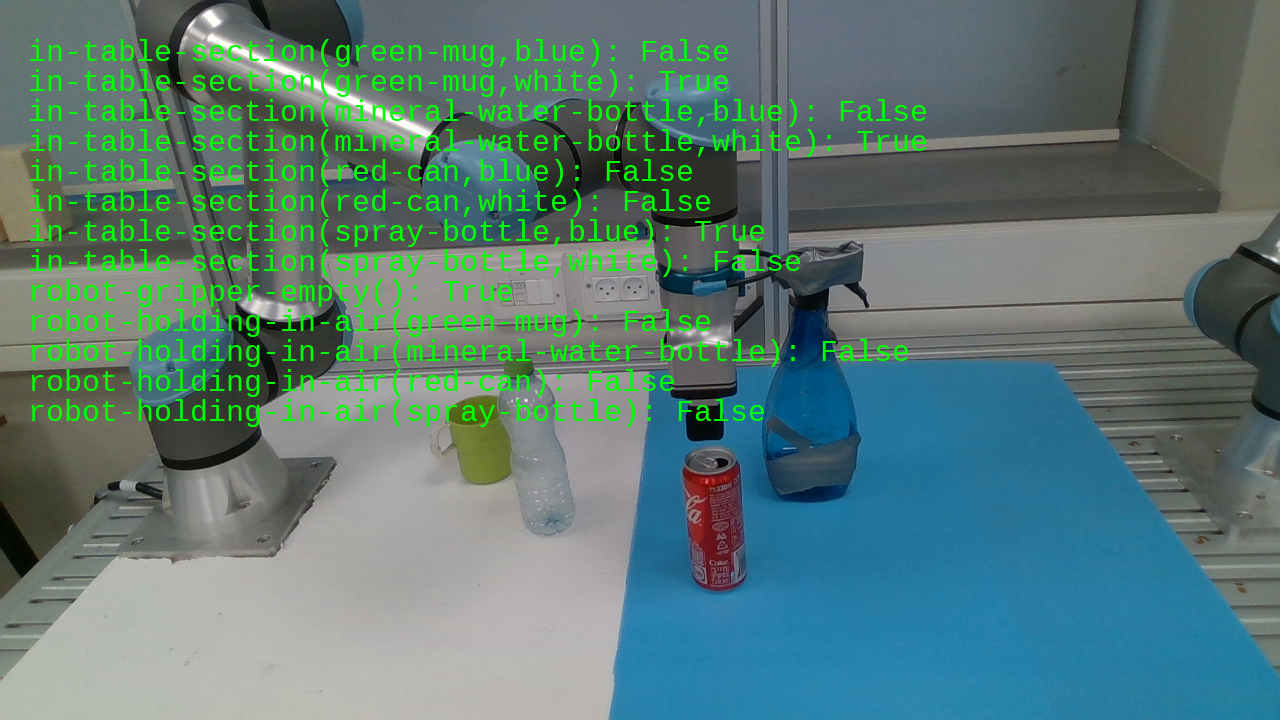

In [7]:
get_annotated_image(frame, res)

In [8]:
import cv2